# DATA MODELING & ANALYSIS

In [2]:
# Import Libraries

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ( accuracy_score,classification_report)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from prophet import Prophet
from statsmodels.tsa.arima.model import ARIMA

In [12]:
# Load data

df = pd.read_csv('cleaned_data.csv')

In [13]:
#Converts order date column into datetime format.

df['order_date'] = pd.to_datetime(df['order_date'])
df['signup_date'] = pd.to_datetime(df['signup_date'])

In [15]:
# RFM Analysis:-

In [25]:
#snapshot date
snapshot_date = (
    df['order_date'].max() +
    pd.Timedelta(days=1)
)
# Create RFM table

rfm = df.groupby('customer_id').agg({

    'order_date':
    lambda x: (
        snapshot_date - x.max()
    ).days,

    'order_id': 'nunique',

    'revenue': 'sum'

})

# Rename column

rfm.columns = [
    'Recency',
    'Frequency',
    'Monetary'
]

#Create RFM scores

rfm['R_score'] = pd.qcut(
    rfm['Recency'],
    5,
    labels=[5,4,3,2,1]
)

rfm['F_score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

rfm['M_score'] = pd.qcut(
    rfm['Monetary'],
    5,
    labels=[1,2,3,4,5]
)

# Final RFM score

rfm['RFM_Score'] = (

    rfm['R_score'].astype(str)

    +

    rfm['F_score'].astype(str)

    +

    rfm['M_score'].astype(str)
)

rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)

# Customer Segmentation

def segment(row):

    if row['RFM_Score'] == '555':
        return 'Champion'

    elif row['F_score'] >= 4:
        return 'Loyal'

    else:
        return 'Regular'

rfm['Segment'] = rfm.apply(
    segment,
    axis=1
)


rfm.head(10)


,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
customer_id,,,,,,,,
1,9,8,2632.0,5,5,5,555,Champion
2,102,3,2075.0,2,3,4,234,Regular
3,40,1,180.0,4,1,1,411,Regular
4,81,4,774.0,3,4,2,342,Loyal
5,36,7,3014.0,4,5,5,455,Loyal
6,192,3,1597.0,1,3,4,134,Regular
7,95,2,1087.0,3,2,3,323,Regular
8,161,2,581.0,2,2,2,222,Regular
9,73,3,961.0,3,3,3,333,Regular


In [ ]:
# Churn Prediction

In [27]:
# Create table variable

rfm['Churn'] = np.where(
    rfm['Recency'] > 90,
    1,
    0
)

# Features & Target

X = rfm[[
    'Recency',
    'Frequency',
    'Monetary'
]]

y = rfm['Churn']


In [31]:
rfm['Churn'].value_counts()

Churn
0    162
1    115
Name: count, dtype: int64

##### *162 Active Customer
##### *115 Chrun Customer

In [35]:
rfm

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment,Churn
customer_id,,,,,,,,,
1,9,8,2632.0,5,5,5,555,Champion,0
2,102,3,2075.0,2,3,4,234,Regular,1
3,40,1,180.0,4,1,1,411,Regular,0
4,81,4,774.0,3,4,2,342,Loyal,0
5,36,7,3014.0,4,5,5,455,Loyal,0
...,...,...,...,...,...,...,...,...,...
296,219,4,2410.0,1,4,5,145,Loyal,1
297,222,1,789.0,1,1,2,112,Regular,1
298,55,1,330.0,4,1,1,411,Regular,0


In [41]:
# Train Test Split

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
)

In [42]:
# Logistic Regression

lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("\nLogistic Regression Accuracy:")
print(
    accuracy_score(
        y_test,
        lr_pred
    )
)


Logistic Regression Accuracy:
1.0


##### A Logistic Regression model achieving 100% accuracy (1.0)

In [43]:
# Random Forest

rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("\nRandom Forest Accuracy:")
print(
    accuracy_score(
        y_test,
        rf_pred
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_pred
    )
)


Random Forest Accuracy:
1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        34
           1       1.00      1.00      1.00        22

    accuracy                           1.00        56
   macro avg       1.00      1.00      1.00        56
weighted avg       1.00      1.00      1.00        56



### INSIGHTS:-
#### *The Random Forest model achieved 100% accuracy, indicating excellent performance in predicting customer churn on the test dataset.
#### *The model correctly classified both:
##### *churn customers (1)
##### *non-churn customers (0)
##### *with perfect prediction performance.
#### *Precision score of 1.00 indicates that all customers predicted as churn/non-churn were classified correctly without false predictions.
#### *Recall score of 1.00 shows that the model successfully identified all actual churn customers and active customers.
#### *F1-score of 1.00 indicates a perfect balance between precision and recall, demonstrating highly reliable model performance.
#### *The results suggest that:
##### *Recency,Frequency,and Monetary valuesare highly effective indicators for predicting customer churn.

In [44]:
# K-Means Clustering

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm[['Recency',
         'Frequency',
         'Monetary']]
)

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

rfm['Cluster'] = kmeans.fit_predict(
    rfm_scaled
)

print("\nCluster Counts:")
print(rfm['Cluster'].value_counts())


Cluster Counts:
Cluster
0    95
2    90
3    50
1    42
Name: count, dtype: int64


### INSIGHTS:-
#### *The KMeans algorithm segmented customers into 4 distinct customer groups based on:
##### *Recency
##### *Frequency
##### *Monetary value
#### *Cluster 0 is the largest segment (95 customers), indicating a major group of customers with similar purchasing behavior.
#### *Cluster 2 also contains a significant number of customers (90), suggesting another important customer category within the business.
#### *Clusters 1 and 3 are comparatively smaller, indicating more specialized customer groups such as:
##### *high-value customers,
##### *inactive customers,
##### *or niche purchasing behaviors.
#### *The uneven distribution of customers across clusters suggests that customer behavior is not uniform and different marketing strategies may be required for each segment.

In [46]:
# Sales Forecasting - ARIMA
sales_series = (
    df.groupby('order_date')['revenue']
    .sum()
)

arima_model = ARIMA(
    sales_series,
    order=(1,1,1)
)

arima_result = arima_model.fit()

forecast_arima = (
    arima_result.forecast(
        steps=30
    )
)

print("\nARIMA Forecast:")
print(forecast_arima)


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



ARIMA Forecast:
335    1155.526649
336    1147.652499
337    1147.484231
338    1147.480635
339    1147.480558
340    1147.480557
341    1147.480557
342    1147.480557
343    1147.480557
344    1147.480557
345    1147.480557
346    1147.480557
347    1147.480557
348    1147.480557
349    1147.480557
350    1147.480557
351    1147.480557
352    1147.480557
353    1147.480557
354    1147.480557
355    1147.480557
356    1147.480557
357    1147.480557
358    1147.480557
359    1147.480557
360    1147.480557
361    1147.480557
362    1147.480557
363    1147.480557
364    1147.480557
Name: predicted_mean, dtype: float64


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


### INSIGHTS:-
#### *The ARIMA model predicts that future sales revenue will stabilize around 1147 units/value per day over the forecast period.
#### *The forecast shows a slight decline initially from 1155.53 to 1147.48, after which the values become nearly constant.
#### *The stable forecast trend suggests that:
##### *sales demand is expected to remain consistent,
##### *with no major upward or downward fluctuations in the near future.
#### *The absence of large variations in forecasted values indicates relatively stable historical sales patterns in the dataset.
#### *The model captures a steady-state sales behavior, which can help businesses in:
##### *inventory planning,
##### *budgeting,
##### *staffing,
##### *and demand forecasting.

In [47]:
#eXPORT FILE
rfm.to_csv(
    "rfm_analysis.csv"
)

In [51]:
# Sales Forecasting - PROPH
forecast_df = (
    df.groupby('order_date')['revenue']
    .sum()
    .reset_index()
)

forecast_df.columns = ['ds', 'y']

prophet_model = Prophet()

prophet_model.fit(forecast_df)

future = prophet_model.make_future_dataframe(
    periods=30
)

forecast = prophet_model.predict(future)

print("\nProphet Forecast:")
print(
    forecast[[
        'ds',
        'yhat',
        'yhat_lower',
        'yhat_upper'
    ]].tail(30)
)

18:09:59 - cmdstanpy - INFO - Chain [1] start processing
18:09:59 - cmdstanpy - INFO - Chain [1] done processing



Prophet Forecast:
            ds         yhat  yhat_lower   yhat_upper
335 2024-12-31  1129.965765  160.000584  2164.893606
336 2025-01-01  1214.662625  217.154147  2203.609049
337 2025-01-02  1051.172743   68.056164  2001.987620
338 2025-01-03  1331.647611  261.884286  2336.524275
339 2025-01-04  1161.834087  138.464995  2209.100088
340 2025-01-05  1025.722329   49.805724  2009.148816
341 2025-01-06  1243.814458  201.318049  2310.130028
342 2025-01-07  1130.761427  105.532098  2090.163441
343 2025-01-08  1215.458286  143.055455  2201.893168
344 2025-01-09  1051.968404   58.404863  2019.647845
345 2025-01-10  1332.443273  313.142903  2353.936221
346 2025-01-11  1162.629748  167.001701  2145.600341
347 2025-01-12  1026.517991   42.707780  2001.757694
348 2025-01-13  1244.610120  293.293293  2100.267429
349 2025-01-14  1131.557088  182.006656  2136.215566
350 2025-01-15  1216.253947  166.263733  2207.279400
351 2025-01-16  1052.764065   50.065819  2072.545213
352 2025-01-17  1333.238934

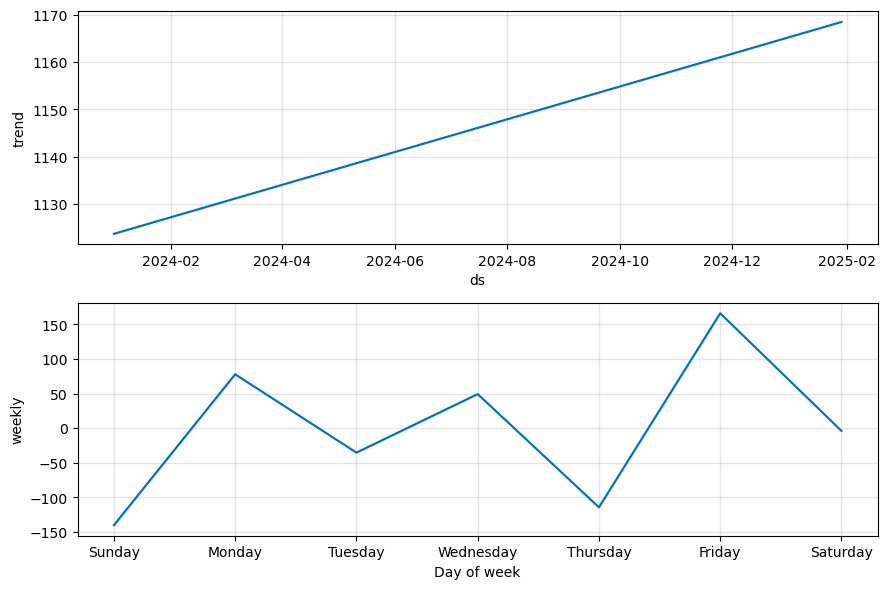

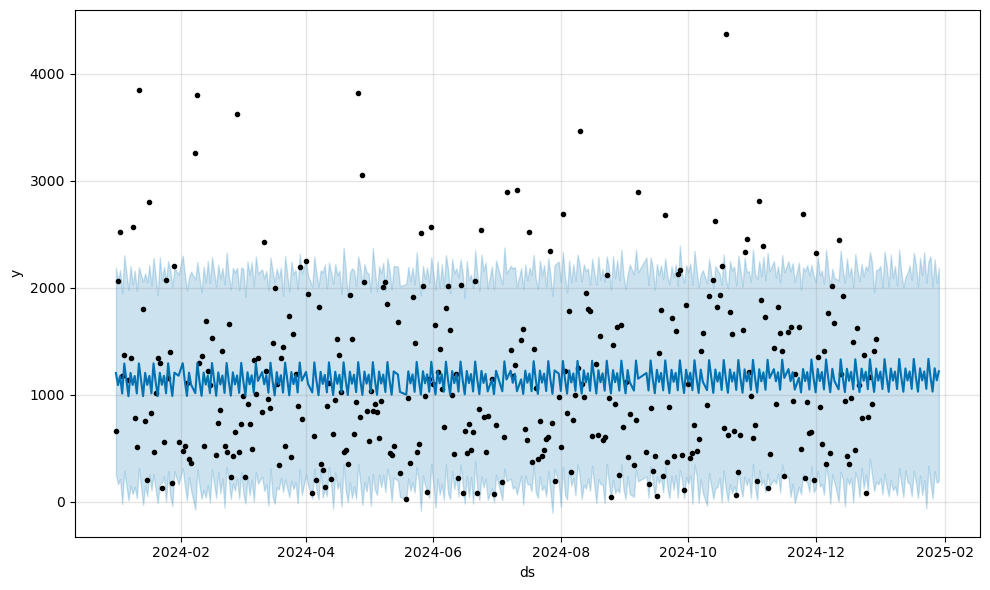

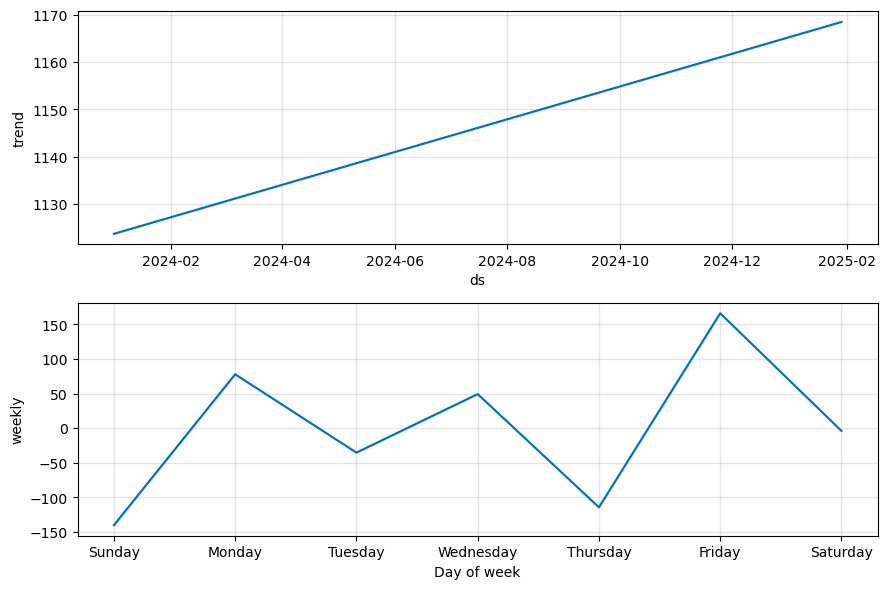

In [54]:
# Visualization
prophet_model.plot(forecast)
prophet_model.plot_components(forecast)

### INSIGHTS:-
#### *The Prophet model forecasts future daily sales revenue in the range of approximately 1000–1350, indicating relatively stable future business performance.
#### *The forecast shows repeating fluctuations across days, suggesting the presence of weekly seasonality patterns in customer purchasing behavior.
#### *Predicted sales peaks occur periodically around values near 1330, indicating certain days may consistently experience higher demand.
#### *Lower forecast values around 1025–1055 suggest comparatively weaker sales periods within the weekly cycle.
#### *The forecast confidence intervals (yhat_lower and yhat_upper) are wide, indicating uncertainty in future predictions and possible variability in customer demand.
#### *Prophet captures both:
##### *trend behavior
##### *and recurring seasonal patterns